In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy.integrate as integrate

from numpy import pi, exp, cos, sin, sqrt, cosh, log, tanh, arcsinh, arctanh
import tinyarray as ta

from scipy.special import j0,k0
import time

import modules.tools as tools
import modules.models as models

In [2]:
import os
import pickle
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/NLSM_flat_band_files


In [3]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [4]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

In [5]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [6]:
def superconducting_Tc(C,G0):
    if C==1.0:
        return G0/4
    elif C==0.0:
        return 0.0
    elif C==2.0:
        return 0.0
    else:
        return G0/4 * (1-C)/arctanh(1-C)

In [7]:
def magnetic_Tc(C,V0):
    return V0/4 * C*(2-C)

## $T_c$ curves

In [8]:
V0 = 1.
G0 = 0.75*V0

In [9]:
NC = 401
Cs = np.linspace(0,2,NC)
Tcs_sc = np.array([superconducting_Tc(C,G0) for C in Cs])
Tcs_mag = magnetic_Tc(Cs,V0)

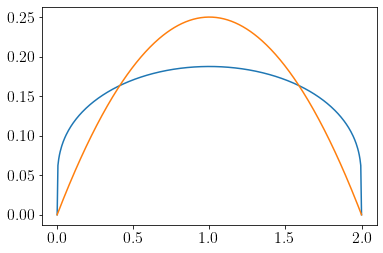

In [10]:
plt.plot(Cs, Tcs_sc)
plt.plot(Cs, Tcs_mag)

#### Save to file for figures

In [17]:
params_save = dict(V0=V0, G0=G0)

In [18]:
# Write everything to a pickle file
path = os.path.dirname(os.getcwd()) + '/data/'
out_name = 'Tc_curves'
fp = open(path + out_name + '.p', 'wb')
pickle.dump(Cs, fp)
pickle.dump(Tcs_sc, fp)
pickle.dump(Tcs_mag, fp)
fp.close()

## General phase diagram

In [11]:
N = 100
Cs = np.linspace(0,2,100)

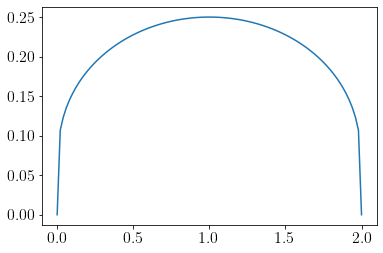

In [12]:
Tcs = np.array([superconducting_Tc(C,1.) for C in Cs])
plt.plot(Cs, Tcs)

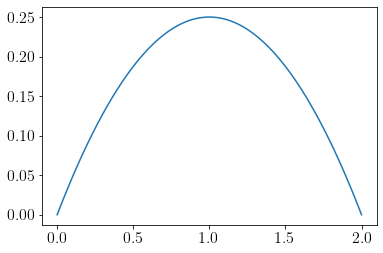

In [13]:
plt.plot(Cs, magnetic_Tc(Cs,1.))

In [14]:
NC = 401
NG = 401
Cs = np.linspace(0,2,NC)
Gs = np.linspace(0,1.5,NG)

phase = np.zeros((NC,NG))

for i,C in enumerate(Cs):
    for j,G in enumerate(Gs):
        phase[i,j] = (superconducting_Tc(C,G) > magnetic_Tc(C,1.))

In [15]:
# determine phase separation line
Gs_sep = np.zeros(NC)

for i,C in enumerate(Cs):
    for j,G in enumerate(Gs):
        if phase[i,j]==True: 
            Gs_sep[i] = (G+Gs[j-1])/2
            break           

Text(0.5, 0.2, 'ferromagnetic')

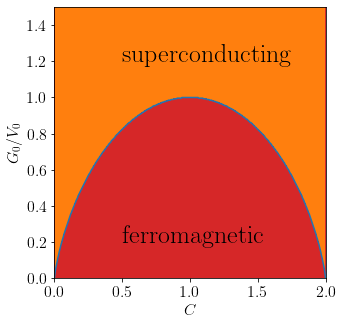

In [16]:
c1=3
c2=1

cmaplist = [colors[c1],colors[c2]]
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, 2)

plt.figure(figsize=(5,5))
plt.imshow(phase.transpose(), extent=tools.imshow_extent(Cs,Gs), origin='lower', 
           aspect=2/1.5, cmap=cmap)
plt.plot(Cs, Gs_sep)
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$C$')
plt.ylabel('$G_0/V_0$')

plt.text(0.5, 1.2, 'superconducting', fontsize=26)
plt.text(0.5, 0.2, 'ferromagnetic', fontsize=26)

#plt.colorbar()

Text(0.5, 0.2, 'ferromagnetic')

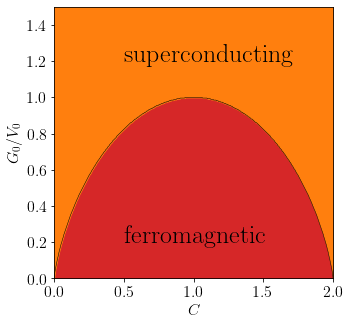

In [17]:
c1=3
c2=1

plt.figure(figsize=(5,5))
plt.plot(Cs, Gs_sep, c='k', lw=0.5)
plt.fill_between(Cs, 0, Gs_sep, color=colors[c1])
plt.fill_between(Cs, Gs_sep, 1.5, color=colors[c2])
plt.xlabel('$C$')
plt.ylabel('$G_0/V_0$')

plt.xlim(0,2)
plt.ylim(0,1.5)

plt.text(0.5, 1.2, 'superconducting', fontsize=26)
plt.text(0.5, 0.2, 'ferromagnetic', fontsize=26)

#### Save to file for figures

In [228]:
#params_save = dict(t1=t1, t2=t2, Nkx=Nx, Nky=Ny)
#other_params = dict(R0=R0, R1=R1, dE=dE)

In [40]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'phase_diagram'
fp = open(path + out_name + '.p', 'wb')
pickle.dump(Cs, fp)
pickle.dump(Gs_sep, fp)
fp.close()